# look at training progress

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import os

In [34]:
pretty  = {"loss":"Loss", "grad_norm": "Gradient norm", "ema_decay": "EMA decay", "n_events": "Events seen", "n_updates": "Gradient updates"}

folder = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/"
trainings = []
dates = []
for date in os.listdir(folder):
    subfolder = os.path.join(folder, date)
    content = os.listdir(subfolder)
    skip = False
    for name in pretty:
        if not f"{name}.npy" in content:
            print(f"date {date} missing {name}")
            skip = True
    if skip:
        continue
    
        
    files = [os.path.join(subfolder, name) for name in os.listdir(subfolder) if name.endswith(".npy")]
    data = {os.path.basename(name)[:-4]: np.load(name) for name in files}
    trainings.append(data)
    dates.append(date.replace("_", " "))


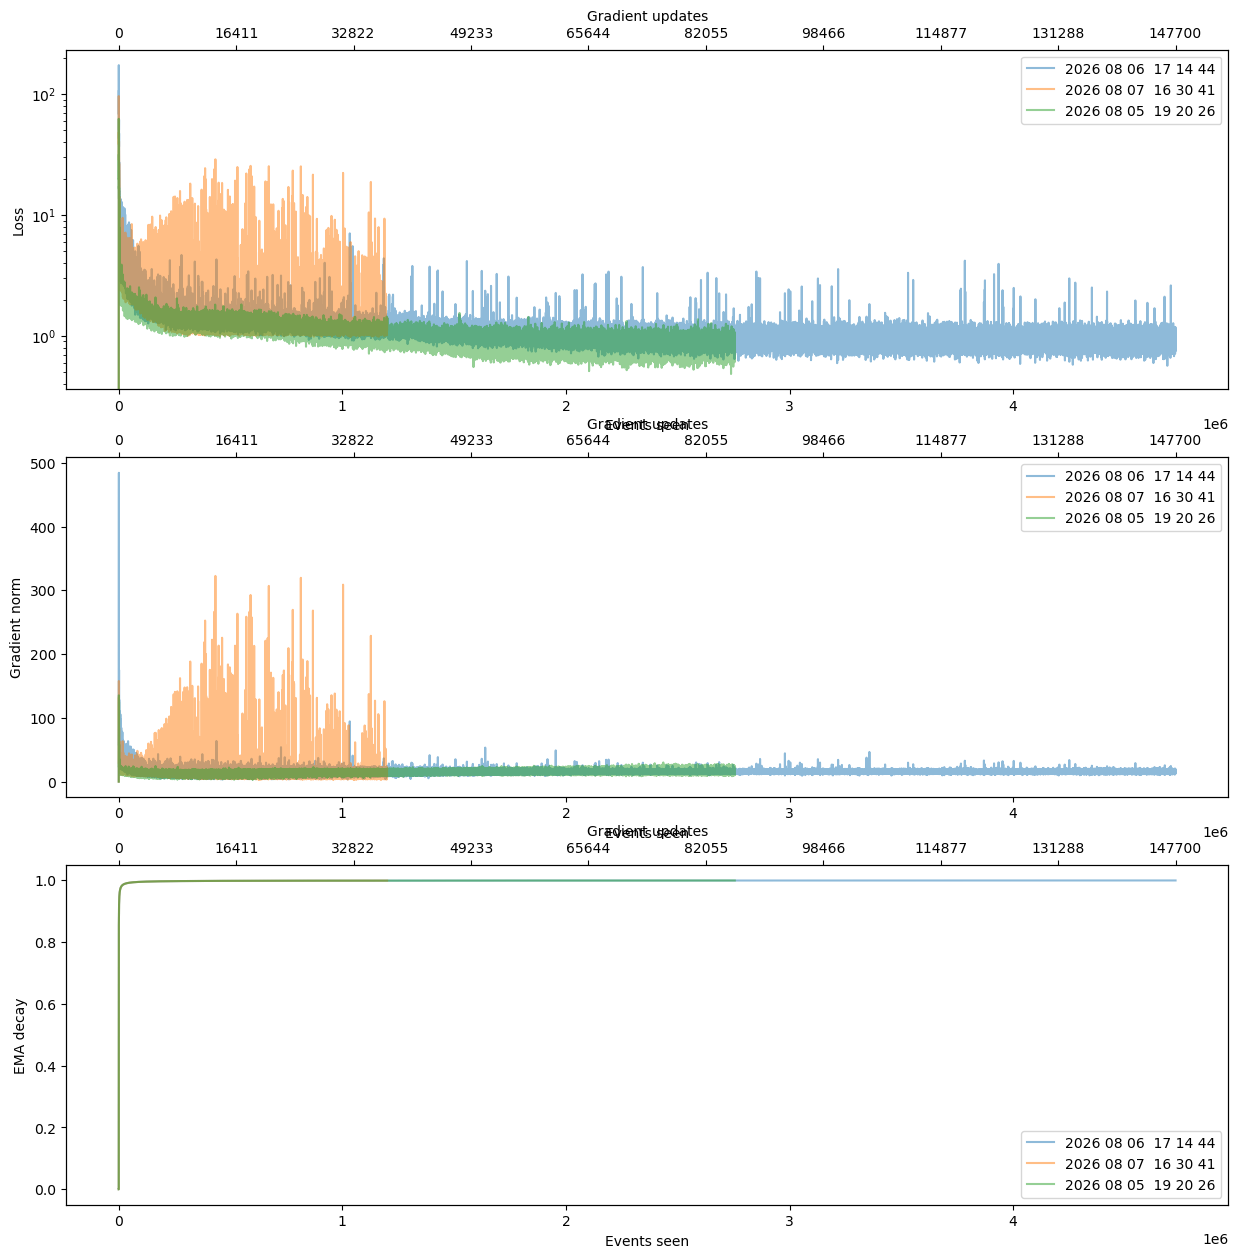

In [37]:
fig, axarr = plt.subplots(3, 1, figsize=(15, 15))
x_name = 'n_events'
y_values = ["loss", "grad_norm", "ema_decay"]
for i, y_name in enumerate(y_values):
    y_label = pretty[y_name]
    ax = axarr[i]

    longest = trainings[0]
    for date, data in zip(dates, trainings):
        if len(data[x_name]) > len(longest[x_name]):
            longest = data
        ax.plot(data[x_name], data[y_name], label=date, alpha=0.5)
    if y_name in ["loss", "gradient_norm"]:
        ax.semilogy()
    ax.set_xlabel(pretty[x_name])
    ax.set_ylabel(y_label)
    
    n_values = len(longest[x_name])
    n_ticks = 10
    value_idxs = np.linspace(0, n_values-1, n_ticks).astype(int)
    positions = [longest[x_name][idx] for idx in value_idxs]
    x_2_name = 'n_updates'
    labels = [longest[x_2_name][idx] for idx in value_idxs]
    ax2 = ax.twiny()          # <- this was missing
    ax2.set_xlim(ax.get_xlim())                   # share the bottom's coordinates
    ax2.set_xticks(positions)
    ax2.set_xticklabels(labels)
    ax2.set_xlabel(pretty[x_2_name])
    ax.legend()

